In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

In [2]:
def parse_keroml_data(file_path):
    """Parse tab-separated KeroML .dat file after the '# Data' section."""
    with open(file_path, 'r') as f:
        lines = f.readlines()

    data_start = None
    for i, line in enumerate(lines):
        if line.startswith('# Data'):
            data_start = i + 2
            break

    if data_start is None:
        raise ValueError('Could not find # Data section in dataset file.')

    headers = lines[data_start].strip().split('\t')
    rows = []
    for line in lines[data_start + 1:]:
        if line.strip() and not line.startswith('#'):
            parts = line.strip().split('\t')
            if len(parts) == len(headers):
                rows.append(parts)

    df_local = pd.DataFrame(rows, columns=headers)

    non_numeric_cols = ['keroml_id', 'mixture_id', 'mixture_name', '2dgc_val_type']
    for col in df_local.columns:
        if col not in non_numeric_cols:
            df_local[col] = pd.to_numeric(df_local[col], errors='coerce')

    return df_local

data_candidates = [
    Path('../model_training/keroml/training_data/keroml_dataset.dat'),
    Path('../../model_training/keroml/training_data/keroml_dataset.dat'),
    Path('keroml_dataset.dat'),
]

existing = [p for p in data_candidates if p.exists()]
if not existing:
    raise FileNotFoundError('Could not find keroml_dataset.dat in known locations.')

# Prefer the largest available file; this usually corresponds to the latest expanded dataset.
dataset_path = max(existing, key=lambda p: p.stat().st_size)

df = parse_keroml_data(dataset_path)
print('Dataset path:', dataset_path.resolve())
print('Dataset shape:', df.shape)
print('Columns:', len(df.columns))
if '2dgc_val_type' in df.columns:
    print('Rows with measured tag:', df['2dgc_val_type'].astype(str).str.lower().eq('measured').sum())
else:
    print('Rows with measured tag: N/A (column missing)')

Dataset path: /Users/aoxo/vscode/turingtrain/model_training/keroml/training_data/keroml_dataset.dat
Dataset shape: (1688, 214)
Columns: 214
Rows with measured tag: 352


In [3]:
target_col = 'cetane_number_val'
feature_cols = [c for c in df.columns if c.startswith('2dgc_')]

class_name_map = {
    'nor_par': 'n_paraffins',
    'iso_par': 'iso_paraffins',
    'mon_nap': 'mono_cycloparaffins',
    'di_nap': 'di_cycloparaffins',
    'tri_nap': 'tri_cycloparaffins',
    'mon_aro': 'mono_aromatics',
    'di_aro': 'di_aromatics',
    'nap_aro': 'cycloaromatics',
    'olef': 'olefins',
    'oxy': 'oxygenates',
    'dien': 'dienes',
    'inde': 'indenes',
}

pat = re.compile(r'^2dgc_([a-z_]+)_c(\d{2})$')

def build_reduced_features(df_input, cols, split_c=12):
    out = pd.DataFrame(index=df_input.index)

    iso_weighted_c = pd.Series(0.0, index=df_input.index)
    iso_total = pd.Series(0.0, index=df_input.index)

    for c in cols:
        m = pat.match(c)
        if m is None:
            continue
        raw_cls, carbon = m.group(1), int(m.group(2))
        cls = class_name_map.get(raw_cls, raw_cls)
        band = 'lowC' if carbon <= split_c else 'highC'
        out_col = f'{cls}_{band}'
        if out_col not in out.columns:
            out[out_col] = 0.0
        col_values = df_input[c].fillna(0.0)
        out[out_col] = out[out_col] + col_values

        cls_total = f'{cls}_total'
        if cls_total not in out.columns:
            out[cls_total] = 0.0
        out[cls_total] = out[cls_total] + col_values

        if raw_cls == 'iso_par':
            iso_weighted_c = iso_weighted_c + carbon * col_values
            iso_total = iso_total + col_values

    for cls in sorted(set(class_name_map.values())):
        low_col = f'{cls}_lowC'
        high_col = f'{cls}_highC'
        if low_col in out.columns and high_col in out.columns:
            total = out[low_col] + out[high_col] + 1e-9
            out[f'{cls}_high_frac'] = out[high_col] / total

    if 'iso_paraffins_lowC' in out.columns and 'iso_paraffins_highC' in out.columns:
        iso_sum = out['iso_paraffins_lowC'] + out['iso_paraffins_highC'] + 1e-9
        out['iso_branch_proxy'] = out['iso_paraffins_highC'] / iso_sum
    else:
        out['iso_branch_proxy'] = 0.0

    out['iso_paraffins_cavg'] = iso_weighted_c / (iso_total + 1e-9)
    out['iso_paraffins_cavg'] = out['iso_paraffins_cavg'].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    out['paraffin_iso_ratio'] = out.get('n_paraffins_total', 0.0) / (out.get('iso_paraffins_total', 0.0) + 1e-9)

    return out

X_reduced_all = build_reduced_features(df, feature_cols, split_c=12)
y_all = df[target_col]

print('Original 2DGC feature count:', len(feature_cols))
print('Reduced feature count:', X_reduced_all.shape[1])
print('Rows with non-null target:', y_all.notna().sum())
display(X_reduced_all.head(3))

Original 2DGC feature count: 210
Reduced feature count: 51
Rows with non-null target: 105


,n_paraffins_lowC,n_paraffins_total,n_paraffins_highC,iso_paraffins_lowC,iso_paraffins_total,iso_paraffins_highC,mono_cycloparaffins_lowC,mono_cycloparaffins_total,mono_cycloparaffins_highC,di_cycloparaffins_lowC,di_cycloparaffins_total,di_cycloparaffins_highC,tri_cycloparaffins_lowC,tri_cycloparaffins_total,tri_cycloparaffins_highC,mono_aromatics_lowC,mono_aromatics_total,mono_aromatics_highC,di_aromatics_lowC,di_aromatics_total,di_aromatics_highC,cycloaromatics_lowC,cycloaromatics_total,cycloaromatics_highC,olefins_lowC,olefins_total,olefins_highC,oxygenates_lowC,oxygenates_total,oxygenates_highC,indenes_lowC,indenes_total,indenes_highC,dienes_lowC,dienes_total,dienes_highC,cycloaromatics_high_frac,di_aromatics_high_frac,di_cycloparaffins_high_frac,dienes_high_frac,indenes_high_frac,iso_paraffins_high_frac,mono_aromatics_high_frac,mono_cycloparaffins_high_frac,n_paraffins_high_frac,olefins_high_frac,oxygenates_high_frac,tri_cycloparaffins_high_frac,iso_branch_proxy,iso_paraffins_cavg,paraffin_iso_ratio
0,13.13,19.666,6.536,13.42,24.266,10.846,20.57,29.982,9.412,6.32,9.231,2.911,0.042,0.042,0.0,8.631,10.271,1.64,1.65,2.12,0.47,2.65,4.41,1.76,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.399093,0.221698,0.315350,0.0,0.0,0.446963,0.159673,0.313922,0.332350,0.0,0.0,0.0,0.446963,12.242191,0.810434
1,12.90,16.295,3.395,18.90,25.975,7.075,18.34,23.841,5.501,5.32,7.890,2.570,0.140,0.140,0.0,13.691,16.221,2.53,1.56,2.48,0.92,4.67,7.15,2.48,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.346853,0.370968,0.325729,0.0,0.0,0.272377,0.155971,0.230737,0.208346,0.0,0.0,0.0,0.272377,11.408662,0.627334
2,13.97,20.065,6.095,19.06,34.155,15.095,14.13,19.042,4.912,3.03,4.042,1.012,0.062,0.062,0.0,12.921,15.091,2.17,0.84,1.15,0.31,5.05,6.38,1.33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.208464,0.269565,0.250371,0.0,0.0,0.441956,0.143794,0.257956,0.303763,0.0,0.0,0.0,0.441956,12.200849,0.587469


In [4]:
if '2dgc_val_type' in df.columns:
    measured_mask = df['2dgc_val_type'].astype(str).str.lower().eq('measured')
    if measured_mask.sum() == 0:
        measured_mask = pd.Series(True, index=df.index)
else:
    measured_mask = pd.Series(True, index=df.index)

mask_known = y_all.notna() & measured_mask
X = X_reduced_all.loc[mask_known].copy()
y = y_all.loc[mask_known].copy()

print(f'Total rows: {len(df)}')
print(f'Measured-tag rows used: {measured_mask.sum()}')
print(f'Labeled rows used for training: {len(y)}')
print(f'Unlabeled rows: {(~y_all.notna()).sum()}')

# Optional branch label support.
# Expected strings: less_branch, mean, more_branch
if 'branch_label' in df.columns:
    branch_raw = df.loc[mask_known, 'branch_label'].astype(str).str.strip().str.lower()
    map_dict = {
        'less': 'less_branch',
        'less_branch': 'less_branch',
        'mean': 'mean',
        'neutral': 'mean',
        'more': 'more_branch',
        'more_branch': 'more_branch',
    }
    branch_label = branch_raw.map(map_dict)
else:
    branch_label = pd.Series(index=X.index, dtype='object')

print('Branch labels available:', branch_label.notna().sum())
print(branch_label.value_counts(dropna=False).head(10))

Total rows: 1688
Measured-tag rows used: 352
Labeled rows used for training: 31
Unlabeled rows: 1583
Branch labels available: 0
NaN    31
Name: count, dtype: int64


In [5]:
def make_ridge(alpha=3.0):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0.0)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha, random_state=42)),
    ])

alpha_grid = [0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_summary = []
for alpha in alpha_grid:
    fold_preds = np.zeros(len(y))
    X_np = X.reset_index(drop=True)
    y_np = y.reset_index(drop=True)
    for tr, te in kfold.split(X_np):
        m = make_ridge(alpha=alpha)
        m.fit(X_np.iloc[tr], y_np.iloc[tr])
        fold_preds[te] = m.predict(X_np.iloc[te])

    cv_summary.append({
        'alpha': alpha,
        'cv_mae': mean_absolute_error(y_np, fold_preds),
        'cv_rmse': np.sqrt(mean_squared_error(y_np, fold_preds)),
        'cv_r2': r2_score(y_np, fold_preds),
    })

cv_df = pd.DataFrame(cv_summary).sort_values('cv_mae').reset_index(drop=True)
best_alpha = float(cv_df.loc[0, 'alpha'])
print('Cross-validation summary (sorted by MAE):')
display(cv_df)
print(f'Chosen alpha: {best_alpha}')

mean_model = make_ridge(alpha=best_alpha)
mean_model.fit(X, y)

mean_pred_train = pd.Series(mean_model.predict(X), index=X.index)
residual_train = y - mean_pred_train

# Out-of-fold predictions for diagnostics and robust residual statistics.
oof_pred = pd.Series(index=X.index, dtype=float)
for tr, te in kfold.split(X):
    tr_idx = X.index[tr]
    te_idx = X.index[te]
    m = make_ridge(alpha=best_alpha)
    m.fit(X.loc[tr_idx], y.loc[tr_idx])
    oof_pred.loc[te_idx] = m.predict(X.loc[te_idx])

oof_residual = y - oof_pred
print(f'OOF MAE:  {mean_absolute_error(y, oof_pred):.3f}')
print(f'OOF RMSE: {np.sqrt(mean_squared_error(y, oof_pred)):.3f}')
print(f'OOF R2:   {r2_score(y, oof_pred):.3f}')

Cross-validation summary (sorted by MAE):


,alpha,cv_mae,cv_rmse,cv_r2
0,10.00,6.322584,9.983175,0.278948
1,30.00,6.490890,9.707056,0.318282
2,3.00,6.880672,10.847613,0.148670
3,100.00,7.154048,10.266002,0.237514
4,1.00,7.558106,11.976495,-0.037741
5,0.30,8.478989,13.667543,-0.351482
6,0.10,9.370225,15.050164,-0.638747
7,0.03,10.144979,15.955702,-0.841880


Chosen alpha: 10.0
OOF MAE:  6.323
OOF RMSE: 9.983
OOF R2:   0.279


In [6]:
# Scenario-width models around the shared mean model.
# less_branch CN should be >= mean, more_branch CN should be <= mean.
delta_less_model = None
delta_more_model = None

min_samples_per_side = 15
less_mask = branch_label == 'less_branch'
more_mask = branch_label == 'more_branch'

if less_mask.sum() >= min_samples_per_side:
    y_delta_less = (y.loc[less_mask] - mean_pred_train.loc[less_mask]).clip(lower=0.0)
    delta_less_model = make_ridge(alpha=max(1.0, best_alpha / 2.0))
    delta_less_model.fit(X.loc[less_mask], y_delta_less)

if more_mask.sum() >= min_samples_per_side:
    y_delta_more = (mean_pred_train.loc[more_mask] - y.loc[more_mask]).clip(lower=0.0)
    delta_more_model = make_ridge(alpha=max(1.0, best_alpha / 2.0))
    delta_more_model.fit(X.loc[more_mask], y_delta_more)

proxy = X['iso_branch_proxy'] if 'iso_branch_proxy' in X.columns else pd.Series(0.0, index=X.index)
proxy_std = float(proxy.std())
if proxy_std < 1e-9:
    proxy_norm = pd.Series(0.0, index=X.index)
else:
    proxy_norm = (proxy - proxy.mean()) / proxy_std

# Use OOF residuals to reduce optimistic width estimates.
abs_oof_res = np.abs(oof_residual.values)
base_width = max(1.0, np.percentile(abs_oof_res, 60))
width_scale = max(0.4, np.percentile(abs_oof_res, 85) - np.percentile(abs_oof_res, 50))

if delta_less_model is not None:
    delta_less = np.maximum(delta_less_model.predict(X), 0.0)
else:
    delta_less = np.maximum(base_width - 0.25 * width_scale * proxy_norm.values, 0.4)

if delta_more_model is not None:
    delta_more = np.maximum(delta_more_model.predict(X), 0.0)
else:
    delta_more = np.maximum(base_width + 0.55 * width_scale * proxy_norm.values, 0.4)

cn_mean = mean_pred_train.values
cn_less = cn_mean + delta_less
cn_more = cn_mean - delta_more

cn_less = np.maximum(cn_less, cn_mean)
cn_more = np.minimum(cn_more, cn_mean)

out_known = pd.DataFrame({
    'cn_true': y.values,
    'cn_less_branch': cn_less,
    'cn_mean': cn_mean,
    'cn_more_branch': cn_more,
    'iso_branch_proxy': proxy.values,
    'branch_label': branch_label.values,
}, index=X.index)

print('Delta models trained:')
print(' less_branch:', delta_less_model is not None)
print(' more_branch:', delta_more_model is not None)
print(f'Width base: {base_width:.3f}, width scale: {width_scale:.3f}')
display(out_known.head(10))

Delta models trained:
 less_branch: False
 more_branch: False
Width base: 4.651, width scale: 5.881


,cn_true,cn_less_branch,cn_mean,cn_more_branch,iso_branch_proxy,branch_label
55,48.80,56.579522,51.751848,47.490002,0.316431,NaN
56,48.30,50.571271,46.457484,40.625087,0.421142,NaN
57,39.20,44.437196,41.252820,33.375719,0.557465,NaN
61,50.40,51.973878,51.207262,38.011089,0.912096,NaN
64,39.60,48.238386,41.254972,40.854972,0.000233,NaN
74,47.10,48.677859,45.075262,38.118247,0.496122,NaN
75,49.30,52.858964,48.371833,43.360793,0.366381,NaN
76,47.30,51.734167,47.444374,41.999191,0.395326,NaN
77,45.90,49.506801,45.560379,39.359780,0.445690,NaN
85,59.77,61.690818,58.985175,50.054863,0.627684,NaN


In [7]:
# Expected CN from branch probabilities.
# Here we compute sample-wise probabilities using the iso_branch_proxy feature.
# If you later add explicit branch annotations, replace this with a learned classifier.
proxy_vals = out_known['iso_branch_proxy'].fillna(0.0)
proxy_z = (proxy_vals - proxy_vals.mean()) / (proxy_vals.std() + 1e-9)

# Smooth mapping: higher proxy -> higher probability of more_branch scenario.
p_more = 1.0 / (1.0 + np.exp(-0.9 * proxy_z))
p_less = 1.0 / (1.0 + np.exp(0.9 * proxy_z))
p_mean = np.clip(1.0 - 0.55 * (p_less + p_more), 0.05, 0.9)

p_sum = p_less + p_mean + p_more
p_less = p_less / p_sum
p_mean = p_mean / p_sum
p_more = p_more / p_sum

out_known['p_less'] = p_less
out_known['p_mean'] = p_mean
out_known['p_more'] = p_more

out_known['cn_expected'] = (
    out_known['p_less'] * out_known['cn_less_branch']
    + out_known['p_mean'] * out_known['cn_mean']
    + out_known['p_more'] * out_known['cn_more_branch']
)

mae_expected = mean_absolute_error(out_known['cn_true'], out_known['cn_expected'])
mae_mean_only = mean_absolute_error(out_known['cn_true'], out_known['cn_mean'])
rmse_expected = np.sqrt(mean_squared_error(out_known['cn_true'], out_known['cn_expected']))
coverage = ((out_known['cn_true'] >= out_known['cn_more_branch']) & (out_known['cn_true'] <= out_known['cn_less_branch'])).mean()

print(f'Expected-CN MAE: {mae_expected:.3f}')
print(f'Mean-only MAE:   {mae_mean_only:.3f}')
print(f'Expected-CN RMSE: {rmse_expected:.3f}')
print(f'Interval coverage [more, less]: {100 * coverage:.1f}%')

display(out_known[['cn_true', 'cn_more_branch', 'cn_mean', 'cn_less_branch', 'cn_expected', 'p_less', 'p_mean', 'p_more']].head(12))

Expected-CN MAE: 3.686
Mean-only MAE:   2.190
Expected-CN RMSE: 4.563
Interval coverage [more, less]: 77.4%


,cn_true,cn_more_branch,cn_mean,cn_less_branch,cn_expected,p_less,p_mean,p_more
55,48.80,47.490002,51.751848,56.579522,52.116410,0.363470,0.310345,0.326185
56,48.30,40.625087,46.457484,50.571271,45.306153,0.288655,0.310345,0.401001
57,39.20,33.375719,41.252820,44.437196,38.029131,0.199684,0.310345,0.489972
61,50.40,38.011089,51.207262,51.973878,42.924045,0.058555,0.310345,0.631100
64,39.60,40.854972,41.254972,48.238386,45.086061,0.556240,0.310345,0.133415
74,47.10,38.118247,45.075262,48.677859,42.788901,0.237848,0.310345,0.451807
75,49.30,43.360793,48.371833,52.858964,48.027203,0.327564,0.310345,0.362091
76,47.30,41.999191,47.444374,51.734167,46.676529,0.306878,0.310345,0.382777
77,45.90,39.359780,45.560379,49.506801,44.040217,0.271618,0.310345,0.418037
85,59.77,50.054863,58.985175,61.690818,54.697275,0.160789,0.310345,0.528866


In [8]:
# Train on labeled rows and infer all rows, including unlabeled samples.
X_all_reduced = X_reduced_all.copy()
cn_mean_all = mean_model.predict(X_all_reduced)

if delta_less_model is not None:
    delta_less_all = np.maximum(delta_less_model.predict(X_all_reduced), 0.0)
else:
    proxy_all = X_all_reduced['iso_branch_proxy'] if 'iso_branch_proxy' in X_all_reduced.columns else pd.Series(0.0, index=X_all_reduced.index)
    proxy_std_all = float(proxy_all.std())
    if proxy_std_all < 1e-9:
        proxy_norm_all = np.zeros(len(proxy_all))
    else:
        proxy_norm_all = ((proxy_all - proxy_all.mean()) / proxy_std_all).values
    delta_less_all = np.maximum(base_width - 0.25 * width_scale * proxy_norm_all, 0.4)

if delta_more_model is not None:
    delta_more_all = np.maximum(delta_more_model.predict(X_all_reduced), 0.0)
else:
    proxy_all = X_all_reduced['iso_branch_proxy'] if 'iso_branch_proxy' in X_all_reduced.columns else pd.Series(0.0, index=X_all_reduced.index)
    proxy_std_all = float(proxy_all.std())
    if proxy_std_all < 1e-9:
        proxy_norm_all = np.zeros(len(proxy_all))
    else:
        proxy_norm_all = ((proxy_all - proxy_all.mean()) / proxy_std_all).values
    delta_more_all = np.maximum(base_width + 0.55 * width_scale * proxy_norm_all, 0.4)

cn_less_all = np.maximum(cn_mean_all + delta_less_all, cn_mean_all)
cn_more_all = np.minimum(cn_mean_all - delta_more_all, cn_mean_all)

proxy_all = X_all_reduced.get('iso_branch_proxy', pd.Series(0.0, index=df.index)).fillna(0.0)
proxy_all_z = (proxy_all - proxy_all.mean()) / (proxy_all.std() + 1e-9)
p_more_all = 1.0 / (1.0 + np.exp(-0.9 * proxy_all_z))
p_less_all = 1.0 / (1.0 + np.exp(0.9 * proxy_all_z))
p_mean_all = np.clip(1.0 - 0.55 * (p_less_all + p_more_all), 0.05, 0.9)
p_all_sum = p_less_all + p_mean_all + p_more_all
p_less_all = p_less_all / p_all_sum
p_mean_all = p_mean_all / p_all_sum
p_more_all = p_more_all / p_all_sum

cn_expected_all = p_less_all * cn_less_all + p_mean_all * cn_mean_all + p_more_all * cn_more_all

results = pd.DataFrame({
    'keroml_id': df.get('keroml_id', pd.Series(index=df.index, dtype='object')),
    'mixture_id': df.get('mixture_id', pd.Series(index=df.index, dtype='object')),
    'mixture_name': df.get('mixture_name', pd.Series(index=df.index, dtype='object')),
    'cetane_number_val': df[target_col],
    'cn_less_branch': cn_less_all,
    'cn_mean': cn_mean_all,
    'cn_more_branch': cn_more_all,
    'cn_expected': cn_expected_all,
    'p_less': p_less_all,
    'p_mean': p_mean_all,
    'p_more': p_more_all,
    'iso_branch_proxy': proxy_all,
})

display(results.head(12))
results.to_csv('keroml_three_output_predictions.csv', index=False)
print('Saved: keroml_three_output_predictions.csv')

,keroml_id,mixture_id,mixture_name,cetane_number_val,cn_less_branch,cn_mean,cn_more_branch,cn_expected,p_less,p_mean,p_more,iso_branch_proxy
0,KERO_TRDS_A0_000000,CHTA_MXTR_A0_00245,POSF 3895 (JP-8),NaN,49.390371,46.074695,38.486454,43.145149,0.211275,0.310345,0.478380,0.446963
1,KERO_TRDS_A0_000001,CHTA_MXTR_A0_00246,POSF 3896 (JP-8),NaN,43.531163,38.649806,34.506062,39.123333,0.369113,0.310345,0.320542,0.272377
2,KERO_TRDS_A0_000002,CHTA_MXTR_A0_00247,POSF 3897 (JP-8),NaN,50.607586,47.247007,39.757553,44.418139,0.215324,0.310345,0.474331,0.441956
3,KERO_TRDS_A0_000003,CHTA_MXTR_A0_00248,POSF 3898 (JP-8),NaN,46.211417,42.509834,35.770588,40.444879,0.247375,0.310345,0.442280,0.403931
4,KERO_TRDS_A0_000004,CHTA_MXTR_A0_00249,POSF 3899 (JET A),NaN,46.668934,44.510011,34.376913,39.036426,0.123231,0.310345,0.566424,0.575950
5,KERO_TRDS_A0_000005,CHTA_MXTR_A0_00250,POSF 3900 (JP-8),NaN,51.309589,47.201341,41.356757,46.037862,0.288086,0.310345,0.401569,0.358585
6,KERO_TRDS_A0_000006,CHTA_MXTR_A0_00251,POSF 3901 (JET A),NaN,46.712928,44.238893,34.799042,39.443936,0.143974,0.310345,0.545682,0.540812
7,KERO_TRDS_A0_000007,CHTA_MXTR_A0_00252,POSF 3902 (JP-8),NaN,52.168370,48.206634,42.039724,46.720361,0.273163,0.310345,0.416492,0.374922
8,KERO_TRDS_A0_000008,CHTA_MXTR_A0_00253,POSF 3938 (JP-8),NaN,52.069488,48.501857,41.467917,46.137187,0.234524,0.310345,0.455131,0.418868
9,KERO_TRDS_A0_000009,CHTA_MXTR_A0_00254,POSF 3939 (JP-5),NaN,44.482340,42.066965,32.498061,37.144635,0.139926,0.310345,0.549729,0.547353


Saved: keroml_three_output_predictions.csv


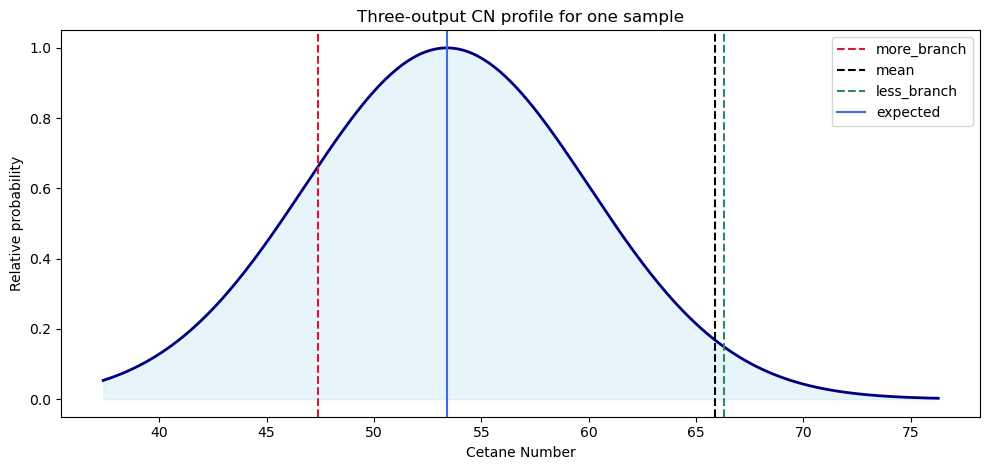

Sample probabilities:
p_less=0.014, p_mean=0.310, p_more=0.675


In [9]:
# Visualize one-sample uncertainty shape (less / mean / more branching).
example_idx = int(results['iso_branch_proxy'].fillna(0).idxmax())
row = results.loc[example_idx]

x_vals = np.linspace(row['cn_more_branch'] - 10, row['cn_less_branch'] + 10, 300)
sigma = max(0.8, 0.35 * (row['cn_less_branch'] - row['cn_more_branch']))
pdf = np.exp(-0.5 * ((x_vals - row['cn_expected']) / sigma) ** 2)
pdf = pdf / (pdf.max() + 1e-12)

plt.figure(figsize=(10, 4.8))
plt.plot(x_vals, pdf, color='navy', lw=2)
plt.fill_between(x_vals, pdf, alpha=0.2, color='skyblue')
plt.axvline(row['cn_more_branch'], linestyle='--', color='crimson', label='more_branch')
plt.axvline(row['cn_mean'], linestyle='--', color='black', label='mean')
plt.axvline(row['cn_less_branch'], linestyle='--', color='seagreen', label='less_branch')
plt.axvline(row['cn_expected'], linestyle='-', color='royalblue', label='expected')
plt.title('Three-output CN profile for one sample')
plt.xlabel('Cetane Number')
plt.ylabel('Relative probability')
plt.legend()
plt.tight_layout()
plt.show()

print('Sample probabilities:')
print(f"p_less={row['p_less']:.3f}, p_mean={row['p_mean']:.3f}, p_more={row['p_more']:.3f}")